# S2: Simulated Data Generation using Drift Diffusion Model

## Purpose
Generate simulated behavioral data using an evidence accumulation framework. 

This scripts serves one purpose:
- (1) Generate a large dataset for study 2, which will quantify the model's prediction.

This script include the original algorithm created by Jiahui Wen, and improved algorithm (parallel processing) by HCP (aided by AI agents). The improvement include:
- (1) More streamlined coding style (aided with ai agents)
- (2) Vectorized data generation (aided with ai agents)
- (3) Added noise to parameter *a* (an issue identified by re-analyzing the S2 results)

## Metadata
- **Random seed**: 42 (set at notebook start)
- **Output file**: 260220.csv (random-space synthetic dataset)
- **Last modified**: 2026-02-15

## Enviroment
This script should be run within the docker container of [`dockerHDDM`](https://hub.docker.com/r/hcp4715/hddm).

In [3]:
# Check current working directory and candidate output locations
from pathlib import Path

cwd = Path.cwd()
print('Current working directory:', cwd)
print('Exists ./work/Study2:', (cwd / 'work' / 'Study2').exists())
print('Notebook directory candidates:')
for p in [cwd, cwd.parent, cwd.parent.parent]:
    print(' -', p)


ls: cannot access './work/Study2': No such file or directory


In [11]:
# Optional environment summary (pure Python fallback, no notebook magics)
try:
    from watermark import watermark
    print(watermark())
except Exception as exc:
    print('watermark not available, skipping optional version banner.')
    print('Reason:', exc)


watermark not available, skipping optional version banner.
Reason: No module named 'watermark'


In [12]:
# =============================================================================
# IMPORTS AND ENVIRONMENT
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import time
import sys
import matplotlib.pyplot as plt

# Print version information for reproducibility
print("Environment versions:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  NumPy: {np.__version__}")
print(f"  SciPy: {__import__('scipy').__version__}")
print(f"  Pandas: {pd.__version__}")


Environment versions:
  Python: 3.13.1
  NumPy: 2.2.0
  SciPy: 1.14.1
  Pandas: 2.2.3


In [3]:
# =============================================================================
# PATHS AND RUNTIME FLAGS
# =============================================================================
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path(r'D:/GitHub_programe/GitHub/Guassion-Process-Experiment-Design'),
]

BASE_DIR = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / '1_Code' / 'Python_for_Generate').exists():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'S2_gen_data_optimized_cp_v2'
OUTPUT_DIR = BASE_DIR / '3_Figures' / 'S2_gen_data_optimized_cp_v2'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

# Execution controls for notebook sections
RUN_BENCHMARK = True
RUN_VALIDATION_PLOTS = True
RUN_LARGE_DATASET = False

# Benchmark and large-run defaults
BENCHMARK_SUBJECTS = 1000
BENCHMARK_TRIALS = 260
LARGE_OUTPUT_FILE = DATA_DIR / '260220.csv'


BASE_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
DATA_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\S2_gen_data_optimized_cp_v2
OUTPUT_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v2


In [4]:
# =============================================================================
# CONFIGURATION - All parameters in one place for reproducibility
# =============================================================================

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# =============================================================================
# MODEL PARAMETERS
# =============================================================================
# Drift rate modifiers
ALPHA1 = 1.5    # Self condition: increases drift rate
ALPHA2 = -0.4   # Stranger condition: smaller effect

# Boundary modifiers
BETA1 = 0.2     # High W (>600): increases boundary
BETA2 = 0       # Low W (<=600): smaller effect

# Sigmoid parameters
GAMMA = 0.1     # Sigmoid steepness for P effect

# Non-decision time
T0 = 0.2        # Seconds

# Simulation settings
DELTA_T = 0.001  # Time step in seconds (1ms)

# Between-subject variability for boundary a
A_CV = 0.15  # Coefficient of variation (15%)

# Condition mapping
CONDITIONS = {0: 'stranger', 1: 'self'}

# Experimental conditions: (P, T, W)



In [5]:
# =============================================================================
# MODEL FUNCTIONS
# =============================================================================

def k_P_func(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    """Sigmoid function for k (P effect) varying with practice."""
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))


def v_P_func(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    """Sigmoid function for P effect on drift rate."""
    k = k_P_func(P, k_min, k_max, gamma, P0)
    return 1 / (1 + np.exp(-k * (P - P1)))


def compute_v(T, P, condition_key):
    """Compute drift rate v based on T, P, and condition."""
    T_0 = 100
    k_T = 0.01

    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_func(P=P, P1=4, k_min=0.01, k_max=0.15, gamma=GAMMA, P0=32)
    v_0 = v_T * v_P * 3

    # Apply condition-specific modifier
    if condition_key == 1:  # self
        v_1 = v_0 * (1 + ALPHA1)
    else:  # stranger
        v_1 = v_0 * (1 + ALPHA2)
    
    return v_1


def compute_a(M):
    """Compute boundary threshold a based on M = T + W."""
    k = 0.01
    M_0 = 600

    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3

    if M > 600:
        a_1 = a_0 * (1 + BETA1)
    else:
        a_1 = a_0 * (1 + BETA2)

    return a_1

In [6]:
# ==============================================================================
# VECTORIZING SIMULATION FUNCTIONS
# ==============================================================================

def simulate_single_trial_vectorized(v, a, t0, max_time_steps, delta_t):
    """
    Simulate a single trial using vectorized noise generation.
    More efficient than generating noise one at a time.
    """
    # Pre-generate all noise for this trial at once
    noise = norm.rvs(loc=0, scale=1, size=max_time_steps) * np.sqrt(delta_t)
    
    # Compute drift component (constant for this trial)
    drift = v * delta_t
    
    # Cumulative evidence
    evidence = a / 2 + np.cumsum(drift + noise)
    
    # Find first boundary crossing
    upper_crossing = np.where(evidence >= a)[0]
    lower_crossing = np.where(evidence <= 0)[0]
    
    if len(upper_crossing) > 0 and len(lower_crossing) > 0:
        # First crossing determines the outcome
        if upper_crossing[0] < lower_crossing[0]:
            return (upper_crossing[0] + 1) * delta_t + t0, 1
        else:
            return (lower_crossing[0] + 1) * delta_t + t0, 2
    elif len(upper_crossing) > 0:
        return (upper_crossing[0] + 1) * delta_t + t0, 1
    elif len(lower_crossing) > 0:
        return (lower_crossing[0] + 1) * delta_t + t0, 2
    else:
        # No decision within time limit
        return max_time_steps * delta_t + t0, 0


In [7]:
# =============================================================================
# ADDITIONAL FUNCTION: Random P, T, W generation
# =============================================================================

def generate_data_random_params(num_subjects, num_trials):
    """
    Generate data with random P, T, W for each subject.
    This is the original '250430.csv' generation function.
    """
    all_data = []
    
    for subject in range(num_subjects):
        # Random P, T, W for each subject
        T = np.random.randint(10, 600)
        P = np.random.randint(0, 150)
        W = np.random.randint(200, 1500)
        M = T + W
        
        # Compute boundary with between-subject variability
        a_base = compute_a(M)
        a = np.random.normal(a_base, a_base * A_CV)
        a = max(a, 0.01)
        
        # Trials per condition
        trials_per_condition = num_trials // 2
        if num_trials % 2 != 0:
            trials_per_condition += 1
        
        max_time = (W + T - T0) * 0.001 + 0.001
        max_time_steps = int(max_time / DELTA_T)
        
        for condition_key in range(2):
            label = CONDITIONS[condition_key]
            
            for trial in range(trials_per_condition):
                v = compute_v(T, P, condition_key)
                v = np.random.normal(v, 1)
                
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, T0, max_time_steps, DELTA_T
                )
                
                if response > 0 and decision_time < max_time:
                    all_data.append({
                        'subjectID': subject + 1,
                        'trialID': trial + 1,
                        'T': T, 'P': P, 'W': W,
                        'Label': label,
                        'v': v, 'a': a,
                        'RT': decision_time,
                        'response': response
                    })
    
    return pd.DataFrame(all_data)

In [13]:
# =============================================================================
# OPTIMIZED: Batch Vectorization + Parallel Processing
# =============================================================================

from joblib import Parallel, delayed

def compute_a_vectorized(M_batch, a_cv=A_CV):
    """Vectorized boundary computation with between-subject variability."""
    k, M_0 = 0.01, 600
    a_0 = 1 / (1 + np.exp(-k * (M_batch - M_0))) * 3
    beta = np.where(M_batch > 600, 1 + BETA1, 1 + BETA2)
    a = a_0 * beta
    if a_cv is not None and a_cv > 0:
        a = a * np.random.normal(1, a_cv, len(M_batch))
    # Handle negative values
    a = np.maximum(a, 0.01)
    return a

def generate_batch_vectorized(subjects_batch, num_trials, base_seed):
    """Process a batch of subjects with vectorized parameter calculations."""
    np.random.seed(base_seed)
    
    n_subjects = len(subjects_batch)
    trials_per_condition = num_trials // 2
    if num_trials % 2 != 0:
        trials_per_condition += 1
    
    # Pre-generate P, T, W for all subjects in batch (vectorized)
    T_batch = np.random.randint(10, 600, n_subjects)
    P_batch = np.random.randint(0, 150, n_subjects)
    W_batch = np.random.randint(200, 1500, n_subjects)
    M_batch = T_batch + W_batch
    
    # Vectorized boundary computation with between-subject variability
    a_batch = compute_a_vectorized(M_batch, a_cv=A_CV)
    
    # Pre-compute max_time for each subject
    max_times = (W_batch + T_batch - T0) * 0.001 + 0.001
    max_time_steps = (max_times / DELTA_T).astype(int)
    
    # Generate trials for each subject
    all_results = []
    
    for i, subject in enumerate(subjects_batch):
        T, P, W, a, max_time, max_ts = (
            T_batch[i], P_batch[i], W_batch[i], a_batch[i],
            max_times[i], max_time_steps[i]
        )
        
        # Process both conditions
        for condition_key in range(2):
            label = CONDITIONS[condition_key]
            
            for trial in range(trials_per_condition):
                # Compute drift rate
                v = compute_v(T, P, condition_key)
                v = np.random.normal(v, 1)
                
                # Simulate trial
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, T0, max_ts, DELTA_T
                )
                
                # Only keep valid trials
                if response > 0 and decision_time < max_time:
                    all_results.append({
                        'subjectID': subject + 1,
                        'trialID': trial + 1,
                        'T': T, 'P': P, 'W': W,
                        'Label': label,
                        'v': v, 'a': a,
                        'RT': decision_time,
                        'response': response
                    })
    
    return pd.DataFrame(all_results)

def generate_data_random_params_optimized(num_subjects, num_trials, batch_size=100, n_jobs=-2):
    """
    Hybrid: Batch vectorization + Parallel processing.
    
    Parameters:
    - num_subjects: Number of subjects to generate
    - num_trials: Number of trials per subject
    - batch_size: Subjects per batch (default 50)
    - n_jobs: Number of parallel jobs (-2 = all cores except 1)
    """
    # Split subjects into batches
    subjects = np.arange(num_subjects)
    n_batches = (num_subjects + batch_size - 1) // batch_size
    batches = np.array_split(subjects, n_batches)
    
    print(f"Processing {num_subjects} subjects in {n_batches} batches (size={batch_size})...")
    
    # Process batches in parallel
    results = Parallel(n_jobs=n_jobs, verbose=1, prefer="threads")(
        delayed(generate_batch_vectorized)(batch, num_trials, SEED + i * 1000)
        for i, batch in enumerate(batches)
    )
    
    # Combine results
    df = pd.concat(results, ignore_index=True)
    return df


In [14]:
# =============================================================================
# VALIDATION: Compare Original vs Optimized
# =============================================================================

if RUN_BENCHMARK:
    print("=" * 60)
    print(f"VALIDATION: Original vs Optimized ({BENCHMARK_SUBJECTS} subjects)")
    print("=" * 60)

    np.random.seed(SEED)
    print("\n1. Original function:")
    start = time.time()
    df_original = generate_data_random_params(BENCHMARK_SUBJECTS, BENCHMARK_TRIALS)
    orig_time = time.time() - start
    print(f"   Time: {orig_time:.2f}s")
    print(f"   Rows: {len(df_original)}, Subjects: {df_original['subjectID'].nunique()}")
    print(f"   Mean RT: {df_original['RT'].mean():.4f}s")
    print(f"   Accuracy: {(df_original['response'] == 1).mean():.4f}")
    print(f"   Mean a: {df_original['a'].mean():.4f} | Std a: {df_original['a'].std():.4f}")
    print(f"   Mean v: {df_original['v'].mean():.4f} | Std v: {df_original['v'].std():.4f}")

    np.random.seed(SEED)
    print("\n2. Optimized function (batch_size=100):")
    start = time.time()
    df_optimized = generate_data_random_params_optimized(
        BENCHMARK_SUBJECTS, BENCHMARK_TRIALS, batch_size=100, n_jobs=-1
    )
    opt_time = time.time() - start
    print(f"   Time: {opt_time:.2f}s")
    print(f"   Rows: {len(df_optimized)}, Subjects: {df_optimized['subjectID'].nunique()}")
    print(f"   Mean RT: {df_optimized['RT'].mean():.4f}s")
    print(f"   Accuracy: {(df_optimized['response'] == 1).mean():.4f}")
    print(f"   Mean a: {df_optimized['a'].mean():.4f} | Std a: {df_optimized['a'].std():.4f}")
    print(f"   Mean v: {df_optimized['v'].mean():.4f} | Std v: {df_optimized['v'].std():.4f}")

    print("\n3. Parameter differences (optimized - original):")
    print(f"   Delta mean a: {df_optimized['a'].mean() - df_original['a'].mean():.4f}")
    print(f"   Delta std a:  {df_optimized['a'].std() - df_original['a'].std():.4f}")
    print(f"   Delta mean v: {df_optimized['v'].mean() - df_original['v'].mean():.4f}")
    print(f"   Delta std v:  {df_optimized['v'].std() - df_original['v'].std():.4f}")
    print(f"\nSpeedup: {orig_time/opt_time:.2f}x")
else:
    print("Benchmark section skipped (RUN_BENCHMARK=False).")

VALIDATION: Original vs Optimized (1000 subjects)

1. Original function:
   Time: 21.09s
   Rows: 193392, Subjects: 1000
   Mean RT: 0.5954s
   Accuracy: 0.9488
   Mean a: 3.0882 | Std a: 1.0606
   Mean v: 4.1814 | Std v: 2.5172

2. Optimized function (batch_size=100):
Processing 1000 subjects in 10 batches (size=100)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   54.8s remaining:  1.4min


   Time: 55.61s
   Rows: 189765, Subjects: 1000
   Mean RT: 0.5936s
   Accuracy: 0.9516
   Mean a: 3.1223 | Std a: 1.0586
   Mean v: 4.2317 | Std v: 2.5201

3. Parameter differences (optimized - original):
   Delta mean a: 0.0341
   Delta std a:  -0.0020
   Delta mean v: 0.0503
   Delta std v:  0.0029

Speedup: 0.38x


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   55.5s finished


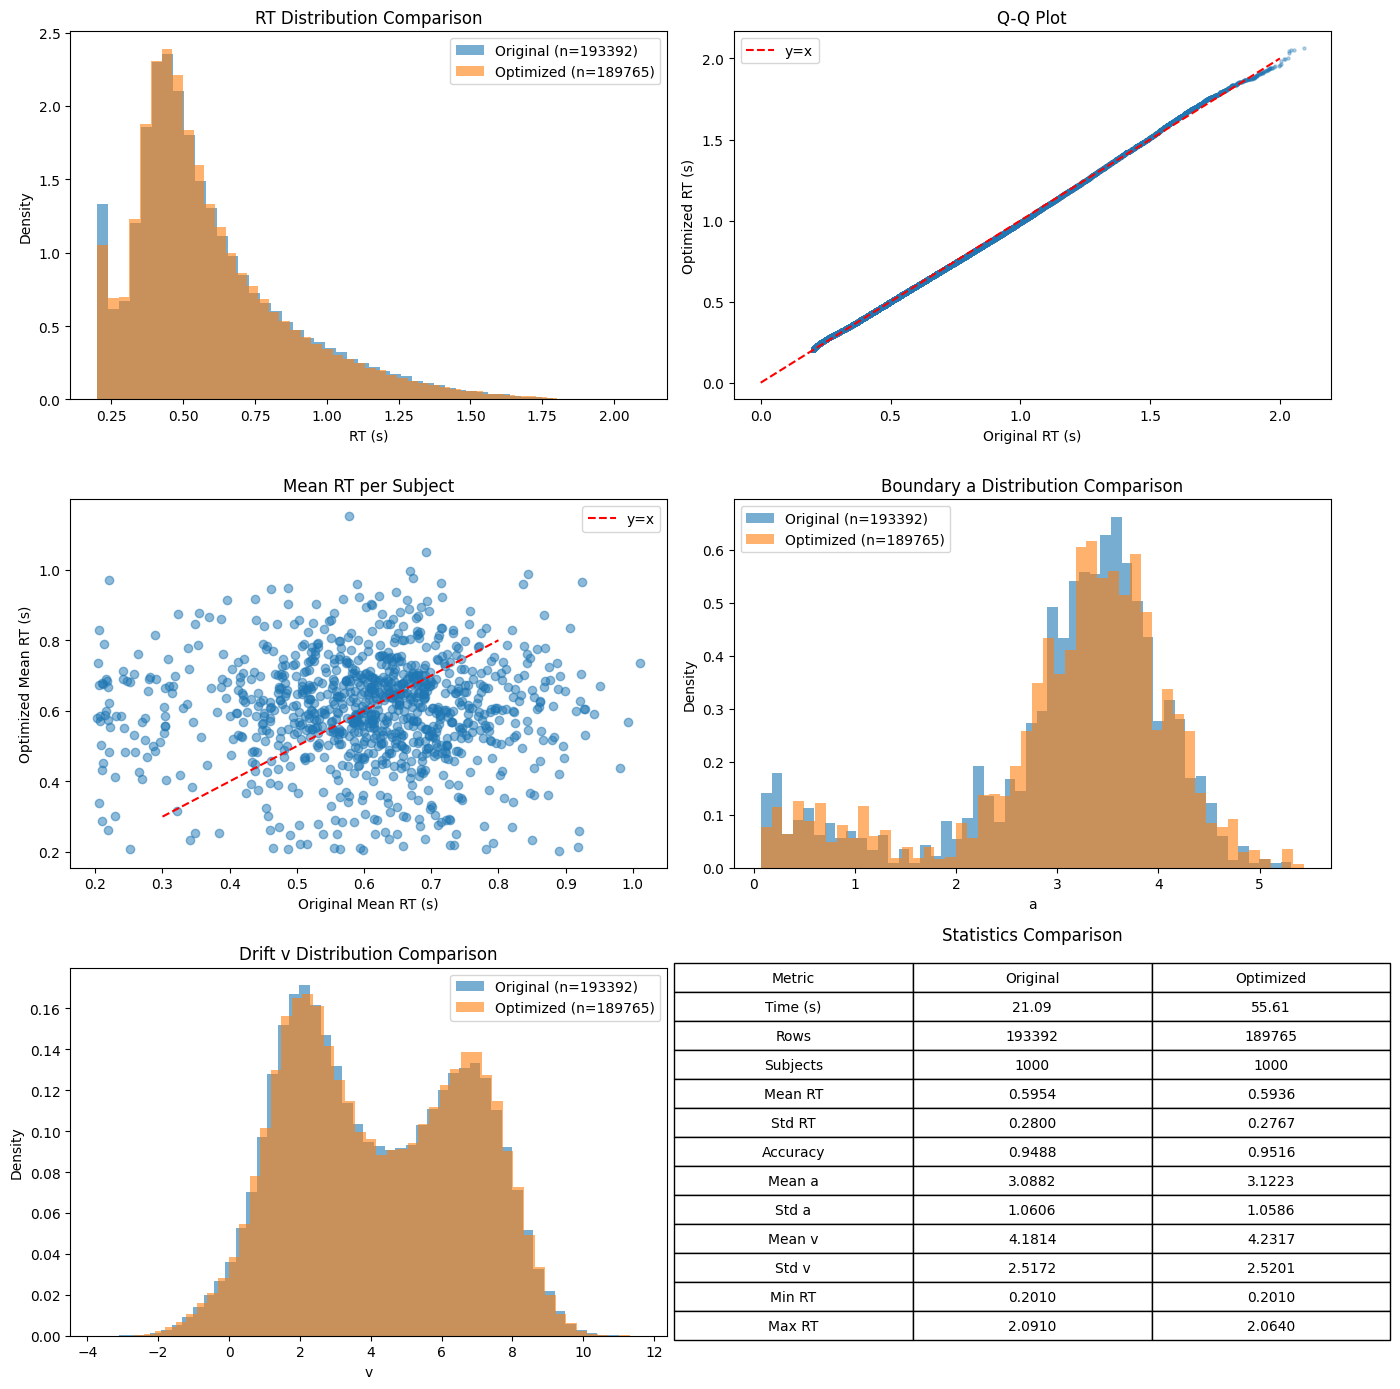


Plot saved to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v2\validation_comparison.png
Memory cleaned up.


In [15]:
# =============================================================================
# VISUALIZATION: Detailed Comparison
# =============================================================================
if RUN_VALIDATION_PLOTS and RUN_BENCHMARK:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    ax1 = axes[0, 0]
    ax1.hist(df_original['RT'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax1.hist(df_optimized['RT'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax1.set_xlabel('RT (s)')
    ax1.set_ylabel('Density')
    ax1.set_title('RT Distribution Comparison')
    ax1.legend()

    ax2 = axes[0, 1]
    min_n = min(len(df_original), len(df_optimized))
    rt_orig = np.sort(df_original['RT'].sample(min_n, random_state=SEED).values)
    rt_opt = np.sort(df_optimized['RT'].sample(min_n, random_state=SEED).values)
    ax2.scatter(rt_orig, rt_opt, alpha=0.3, s=5)
    ax2.plot([0, 2], [0, 2], 'r--', label='y=x')
    ax2.set_xlabel('Original RT (s)')
    ax2.set_ylabel('Optimized RT (s)')
    ax2.set_title('Q-Q Plot')
    ax2.legend()

    ax3 = axes[1, 0]
    orig_subject_means = df_original.groupby('subjectID')['RT'].mean()
    opt_subject_means = df_optimized.groupby('subjectID')['RT'].mean()
    ax3.scatter(orig_subject_means, opt_subject_means, alpha=0.5)
    ax3.plot([0.3, 0.8], [0.3, 0.8], 'r--', label='y=x')
    ax3.set_xlabel('Original Mean RT (s)')
    ax3.set_ylabel('Optimized Mean RT (s)')
    ax3.set_title('Mean RT per Subject')
    ax3.legend()

    ax4 = axes[1, 1]
    ax4.hist(df_original['a'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax4.hist(df_optimized['a'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax4.set_xlabel('a')
    ax4.set_ylabel('Density')
    ax4.set_title('Boundary a Distribution Comparison')
    ax4.legend()

    ax5 = axes[2, 0]
    ax5.hist(df_original['v'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax5.hist(df_optimized['v'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax5.set_xlabel('v')
    ax5.set_ylabel('Density')
    ax5.set_title('Drift v Distribution Comparison')
    ax5.legend()

    ax6 = axes[2, 1]
    ax6.axis('off')
    stats_data = {
        'Metric': ['Time (s)', 'Rows', 'Subjects', 'Mean RT', 'Std RT', 'Accuracy', 'Mean a', 'Std a', 'Mean v', 'Std v', 'Min RT', 'Max RT'],
        'Original': [
            f'{orig_time:.2f}', f'{len(df_original)}', f'{df_original["subjectID"].nunique()}',
            f'{df_original["RT"].mean():.4f}', f'{df_original["RT"].std():.4f}',
            f'{(df_original["response"] == 1).mean():.4f}', f'{df_original["a"].mean():.4f}',
            f'{df_original["a"].std():.4f}', f'{df_original["v"].mean():.4f}',
            f'{df_original["v"].std():.4f}', f'{df_original["RT"].min():.4f}',
            f'{df_original["RT"].max():.4f}'
        ],
        'Optimized': [
            f'{opt_time:.2f}', f'{len(df_optimized)}', f'{df_optimized["subjectID"].nunique()}',
            f'{df_optimized["RT"].mean():.4f}', f'{df_optimized["RT"].std():.4f}',
            f'{(df_optimized["response"] == 1).mean():.4f}', f'{df_optimized["a"].mean():.4f}',
            f'{df_optimized["a"].std():.4f}', f'{df_optimized["v"].mean():.4f}',
            f'{df_optimized["v"].std():.4f}', f'{df_optimized["RT"].min():.4f}',
            f'{df_optimized["RT"].max():.4f}'
        ]
    }
    stats_df = pd.DataFrame(stats_data)
    table = ax6.table(cellText=stats_df.values, colLabels=stats_df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax6.set_title('Statistics Comparison', pad=20)

    plt.tight_layout()
    plot_path = OUTPUT_DIR / "validation_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved to: {plot_path}")

    del df_original, df_optimized
    import gc
    gc.collect()
    print("Memory cleaned up.")
else:
    print("Validation plots skipped (RUN_VALIDATION_PLOTS=False or RUN_BENCHMARK=False).")

In [ ]:
# =============================================================================
# GENERATE LARGE DATASET (250430.csv equivalent)
# =============================================================================

# Generate large dataset with random P, T, W for model fitting
NUM_SUBJECTS_LARGE = 300000  # ~ 4.42 Gb
NUM_TRIALS_LARGE = 260

if RUN_LARGE_DATASET:
    print(f"\nGenerating large dataset: {NUM_SUBJECTS_LARGE} subjects...")
    large_start = time.time()
    np.random.seed(SEED)

    df_large = generate_data_random_params_optimized(
        NUM_SUBJECTS_LARGE, NUM_TRIALS_LARGE, batch_size=100, n_jobs=-1
    )
    df_large.to_csv(LARGE_OUTPUT_FILE, index=False)

    large_time = time.time() - large_start
    print(f"{LARGE_OUTPUT_FILE}: {len(df_large)} rows, {df_large['subjectID'].nunique()} subjects")
    print(f"Time: {large_time:.2f}s")
else:
    print("Large dataset section skipped (RUN_LARGE_DATASET=False).")

In [ ]:
# Pure Python package summary
packages = {
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scipy': __import__('scipy').__version__,
    'matplotlib': plt.matplotlib.__version__,
}
for name, version in packages.items():
    print(f'{name}: {version}')
